In [ ]:
# Python standard library
import os

# Third-party libraries
from dotenv import load_dotenv
import numpy as np
import pandas as pd

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DIR = "/content/drive/MyDrive/Colab Notebooks/MNA/Proyecto Integrador/clear-equity-cards"
os.chdir(DIR)

In [ ]:
import os
from dotenv import load_dotenv

load_dotenv(override=True)

# Sobrescribimos la variable de entorno para Colab DESPUÉS de cargar el .env
os.environ["PROJECT_ROOT"] = "/content/drive/MyDrive/Colab Notebooks/MNA/Proyecto Integrador/clear-equity-cards"

PROJECT_ROOT = os.getenv("PROJECT_ROOT")
if not PROJECT_ROOT:
    raise EnvironmentError("PROJECT_ROOT is not set. Check your .env file.")

os.chdir(PROJECT_ROOT)
print(f"Directorio de trabajo actual: {os.getcwd()}")


Directorio de trabajo actual: /content/drive/MyDrive/Colab Notebooks/MNA/Proyecto Integrador/clear-equity-cards


In [ ]:
results_df = pd.read_csv("02_output_model_experiments/qwen_flores200_token_counts_langinfo.csv")

# Get list of models
model_list = results_df["model"].unique().tolist()

In [ ]:
def gini(x):
    """
    Compute the Gini coefficient of a dataset using the sorting shortcut.

    G = (2 * sum(i * x_i)) / (n * sum(x_i)) - (n + 1) / n

    where x_i are sorted ascending and i in {1, 2, ... , n}

    Parameters
    ----------
    x : array-like
        Non-negative values (e.g., incomes, wealth). Must contain at
        least one positive value.

    Returns
    -------
    float
        Gini coefficient, ranging from 0 (perfect equality) to
        just under 1 (maximal inequality).
    """
    x = np.asarray(x, dtype=np.float64).flatten()

    if np.any(x < 0):
        raise ValueError("Gini coefficient requires non-negative values.")
    if x.sum() == 0:
        raise ValueError("Gini coefficient is undefined when all values are zero.")

    n = len(x)
    x_sorted = np.sort(x)
    ranks = np.arange(1, n + 1)

    return (2 * np.sum(ranks * x_sorted)) / (n * np.sum(x_sorted)) - (n + 1) / n

In [ ]:
gini_results = []
ratio_results = []

for model in model_list:
    calc_data = results_df.loc[results_df["model"] == model,]

    for N in np.arange(2, 200 + 1, step = 1):
        token_count_vector = calc_data.loc[calc_data["cc_spk_rank"] <= N, "token_count"]

        # Gini coefficient
        g = gini(token_count_vector)
        gini_result_i = {"model": model, "N": N, "gini": g}
        gini_results.append(gini_result_i)

        # Max/min ratio
        max_min_ratio = token_count_vector.max() / token_count_vector.min()
        ratio_result_i = {"model": model, "N": N, "max_min_ratio": max_min_ratio}
        ratio_results.append(ratio_result_i)

gini_df = pd.DataFrame(data = gini_results)
ratio_df = pd.DataFrame(data = ratio_results)

In [ ]:
out_N_list = [5, 10, 20, 50, 100, 150, 200]

gini_df_long = gini_df.loc[gini_df["N"].isin(out_N_list),]
gini_df_long["gini"] = gini_df_long["gini"].round(2)

ratio_df_long = ratio_df.loc[ratio_df["N"].isin(out_N_list),]
ratio_df_long["max_min_ratio"] = ratio_df_long["max_min_ratio"].round(1)

gini_df_wide = gini_df_long.pivot(index="model", columns="N", values="gini")
gini_df_wide.columns = ["gini_" + str(N) for N in out_N_list]
gini_df_wide = gini_df_wide.reset_index(drop = False)
gini_df_wide = gini_df_wide.sort_values(by = "gini_200", ascending = True, ignore_index = True)

ratio_df_wide = ratio_df_long.pivot(index="model", columns="N", values="max_min_ratio")
ratio_df_wide.columns = ["max_min_ratio_" + str(N) for N in out_N_list]
ratio_df_wide = ratio_df_wide.reset_index(drop = False)
ratio_df_wide = ratio_df_wide.sort_values(by = "max_min_ratio_200", ascending = True, ignore_index = True)

/tmp/ipykernel_485/1928151465.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gini_df_long["gini"] = gini_df_long["gini"].round(2)
/tmp/ipykernel_485/1928151465.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ratio_df_long["max_min_ratio"] = ratio_df_long["max_min_ratio"].round(1)


In [ ]:
gini_df.to_csv("03_output_analysis/qwen_gini_flores200.csv", index = False)
ratio_df.to_csv("03_output_analysis/qwen_ratio_flores200.csv", index = False)

gini_df_wide.to_csv("03_output_analysis/qwen_gini_for_table_flores200.csv", index = False)
ratio_df_wide.to_csv("03_output_analysis/qwen_ratio_for_table_flores200.csv", index = False)

# TODO: move gini() function to new src/util/equity_metrics file/folder



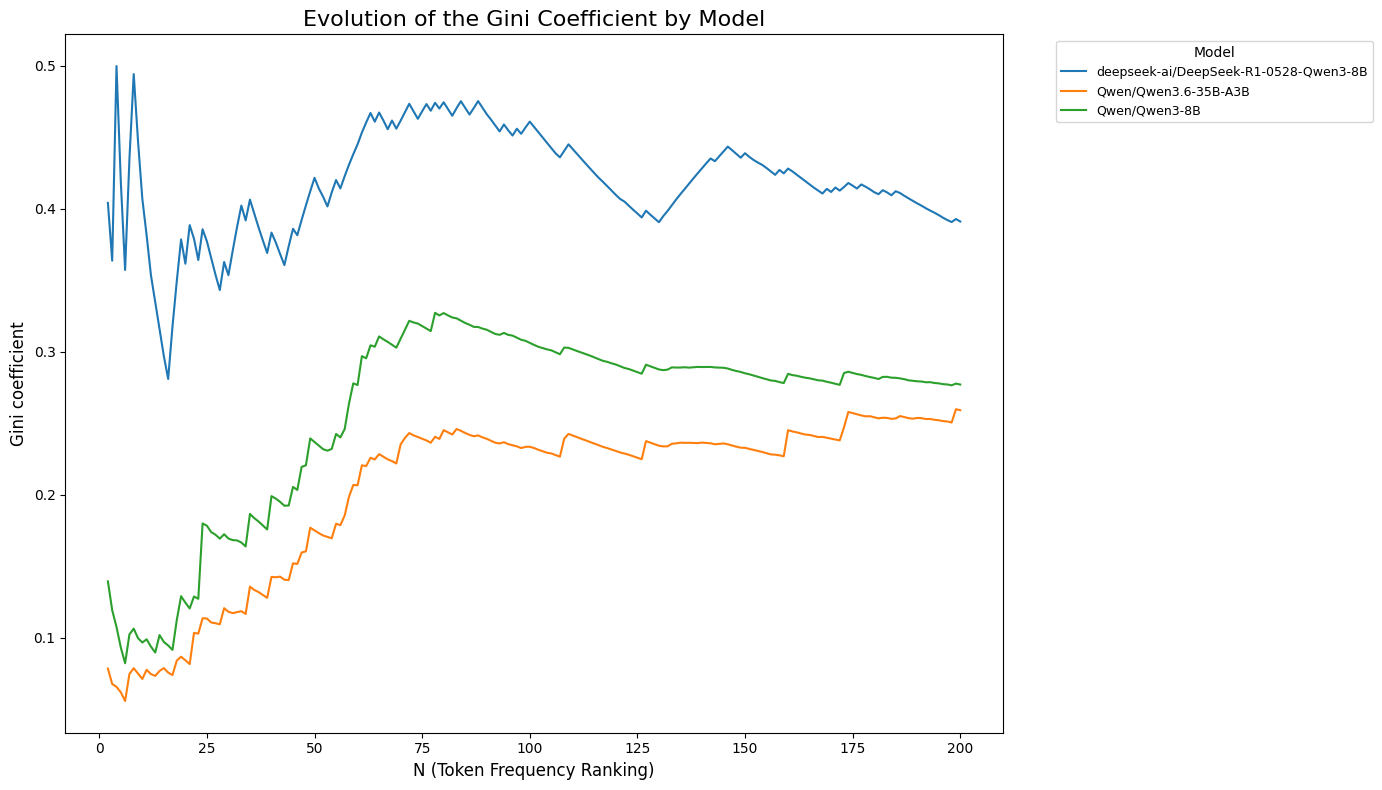

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos el tamaño del gráfico
plt.figure(figsize=(14, 8))

# Creamos el gráfico de líneas usando el dataframe gini_df
sns.lineplot(data=gini_df, x='N', y='gini', hue='model')

# Añadimos títulos y etiquetas
plt.title('Evolution of the Gini Coefficient by Model', fontsize=16)
plt.xlabel('N (Token Frequency Ranking)', fontsize=12)
plt.ylabel('Gini coefficient', fontsize=12)

# Movemos la leyenda fuera del gráfico para que no tape las líneas
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Model', fontsize=9)

# Ajustamos el layout y mostramos el gráfico
plt.tight_layout()
plt.show()

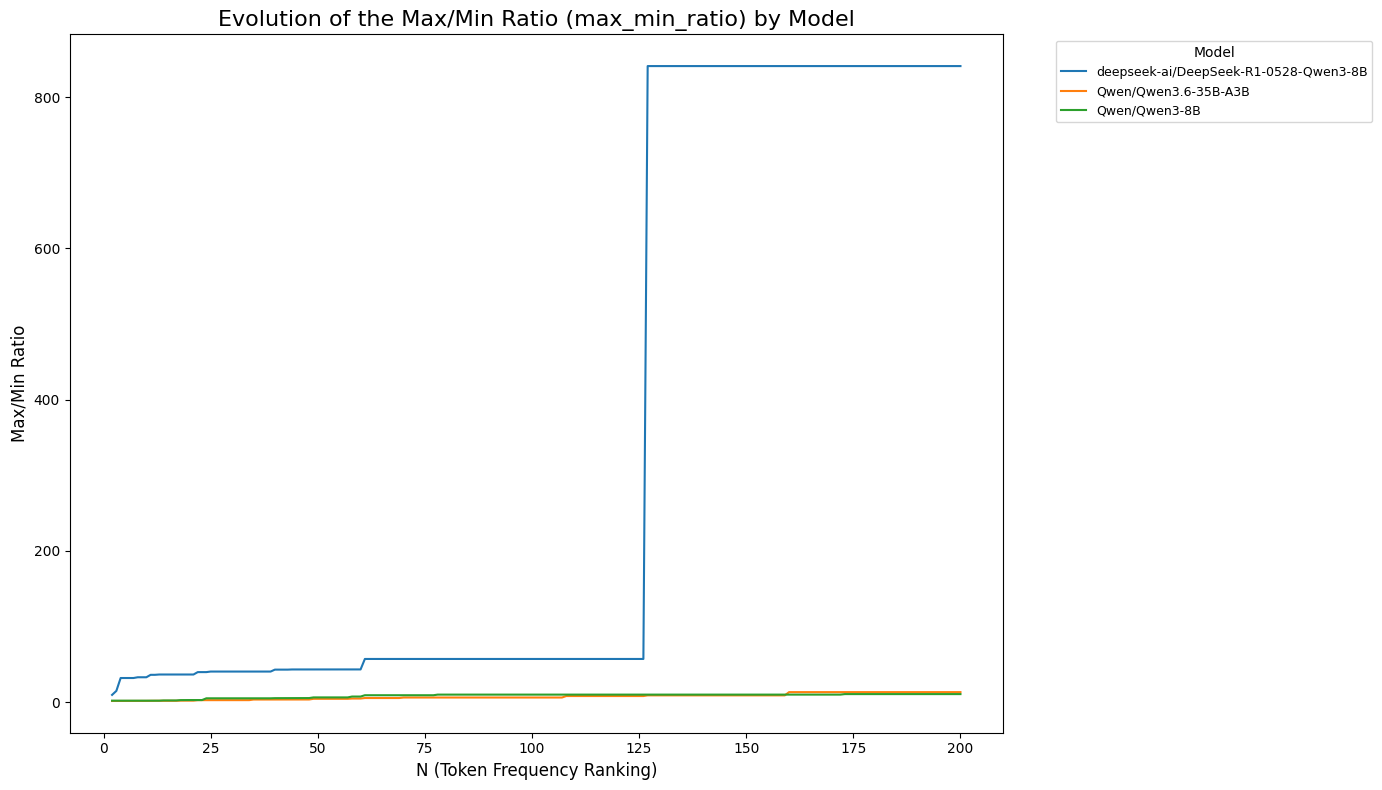

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos el tamaño del gráfico
plt.figure(figsize=(14, 8))

# Creamos el gráfico de líneas usando el dataframe ratio_df
sns.lineplot(data=ratio_df, x='N', y='max_min_ratio', hue='model')

# Añadimos títulos y etiquetas
plt.title('Evolution of the Max/Min Ratio (max_min_ratio) by Model', fontsize=16)
plt.xlabel('N (Token Frequency Ranking)', fontsize=12)
plt.ylabel('Max/Min Ratio', fontsize=12)

# Movemos la leyenda fuera del gráfico para que no tape las líneas
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Model', fontsize=9)

# Ajustamos el layout y mostramos el gráfico
plt.tight_layout()
plt.show()

In [ ]:
# Unimos los dataframes completos para calcular la correlación global
full_merged = pd.merge(gini_df, ratio_df, on=['model', 'N'])

# Calculamos la correlación de Pearson general (todos los valores de N)
corr_general = full_merged['gini'].corr(full_merged['max_min_ratio'])
print(f"General correlation (all N): {corr_general:.4f}")

# Calculamos la correlación específicamente para N=200 (usando el dataframe de la celda anterior)
merged_200 = full_merged[full_merged['N'] == 200]
corr_200 = merged_200['gini'].corr(merged_200['max_min_ratio'])
print(f"Correlation for N=200: {corr_200:.4f}")


General correlation (all N): 0.4797
Correlation for N=200: 0.9918


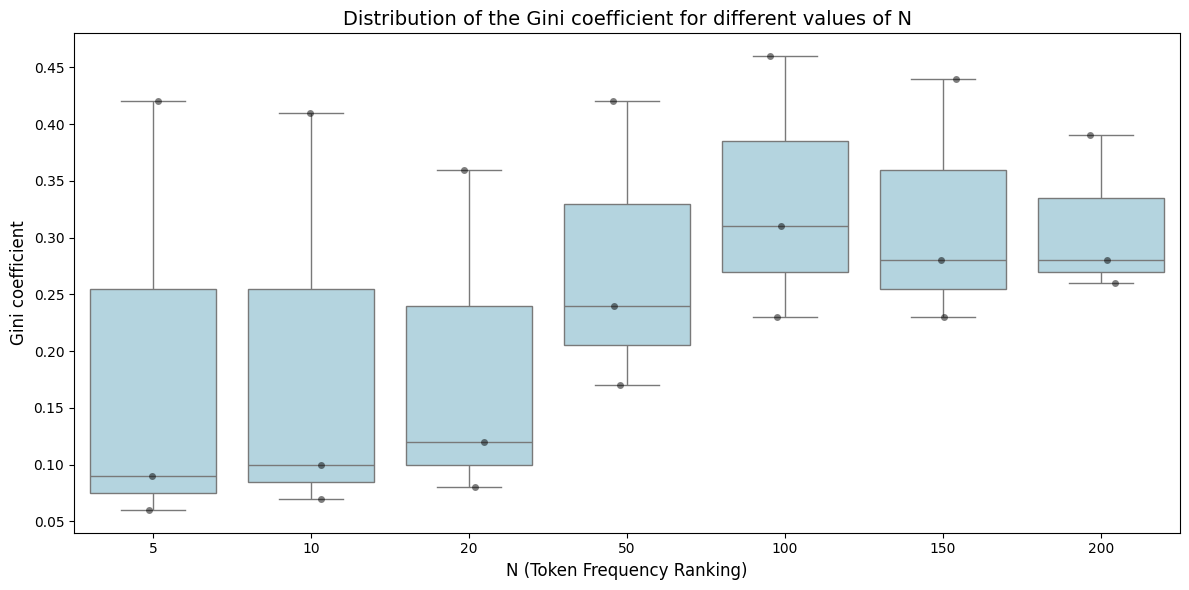

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos el tamaño del gráfico
plt.figure(figsize=(12, 6))

# Creamos un boxplot para ver la distribución del Gini para los valores específicos de N
sns.boxplot(data=gini_df_long, x='N', y='gini', color='lightblue', showfliers=False)

# Añadimos stripplot para ver los puntos individuales de cada modelo
sns.stripplot(data=gini_df_long, x='N', y='gini', color='black', alpha=0.5, jitter=True)

# Añadimos títulos y etiquetas
plt.title('Distribution of the Gini coefficient for different values ​​of N', fontsize=14)
plt.xlabel('N (Token Frequency Ranking)', fontsize=12)
plt.ylabel('Gini coefficient', fontsize=12)

# Ajustamos el layout y mostramos el gráfico
plt.tight_layout()
plt.show()

### Model Comparison & Interpretation of Results

Based on the analysis and visualizations generated above, we can draw several key insights regarding the token distribution equity between the **Qwen/Qwen3-8B**, **Qwen/Qwen3.6-35B-A3B**, and **deepseek-ai/DeepSeek-R1-0528-Qwen3-8B** models across different language counts ($N$):

#### 1. Gini Coefficient Evolution (Equity Analysis)
* **Overall Trend:** For all models, the Gini coefficient generally increases as we include more languages (higher $N$) since lower-resource languages with fewer tokens are introduced into the distribution.
* **Comparative Performance:**
  * **Qwen/Qwen3.6-35B-A3B** consistently exhibits the lowest Gini coefficient across almost all values of $N$ (e.g., $0.26$ at $N=200$). This indicates it has the **most equitable** overall token allocation across languages.
  * **Qwen/Qwen3-8B** displays a slightly higher Gini coefficient (e.g., $0.28$ at $N=200$), indicating moderately balanced distribution.
  * **deepseek-ai/DeepSeek-R1-0528-Qwen3-8B** consistently exhibits a significantly higher Gini coefficient across all levels of $N$ (e.g., $0.39$ at $N=200$), demonstrating the highest level of overall inequality in token representation among the three models.

#### 2. Max/Min Ratio Evolution
* **Boundary Extremes & Divergence:**
  * **Qwen/Qwen3.6-35B-A3B** and **Qwen/Qwen3-8B** maintain relatively low and stable max-to-min ratios (ranging between $1.4$ to $13.1$ across the different values of $N$). Although Qwen3.6-35B-A3B is more equitable overall, its ratio spikes to $13.1$ at $N=200$ compared to Qwen3-8B's $10.5$.
  * **deepseek-ai/DeepSeek-R1-0528-Qwen3-8B** displays extremely high max/min ratios across the board, starting at $31.7$ at $N=5$ and surging drastically to **$840.9$** at $N=200$. This indicates an extreme disparity between the most-represented and least-represented languages in the DeepSeek model.

#### 3. Correlation Analysis
* **General Correlation (0.4797):** Across the entire dataset of all $N$ values and models, there is a moderate positive correlation between the Gini coefficient and the Max/Min ratio.
* **Measurement Differences:** This analysis highlights that while the Gini coefficient measures **overall distributional equity** (meaning most languages have balanced token shares, which keeps Qwen3.6's Gini low despite a minor tail outlier), the Max/Min ratio focuses purely on **boundary extremes**, exposing severe outliers at the very bottom of the distribution (as seen spectacularly with the DeepSeek model).